# Depth of particle advection

In [3]:
import sys
from goa_import import *
import matplotlib.colors as mcolors
HOME='/oscar/data/deeps/private/ediloren/ebeaudin/'

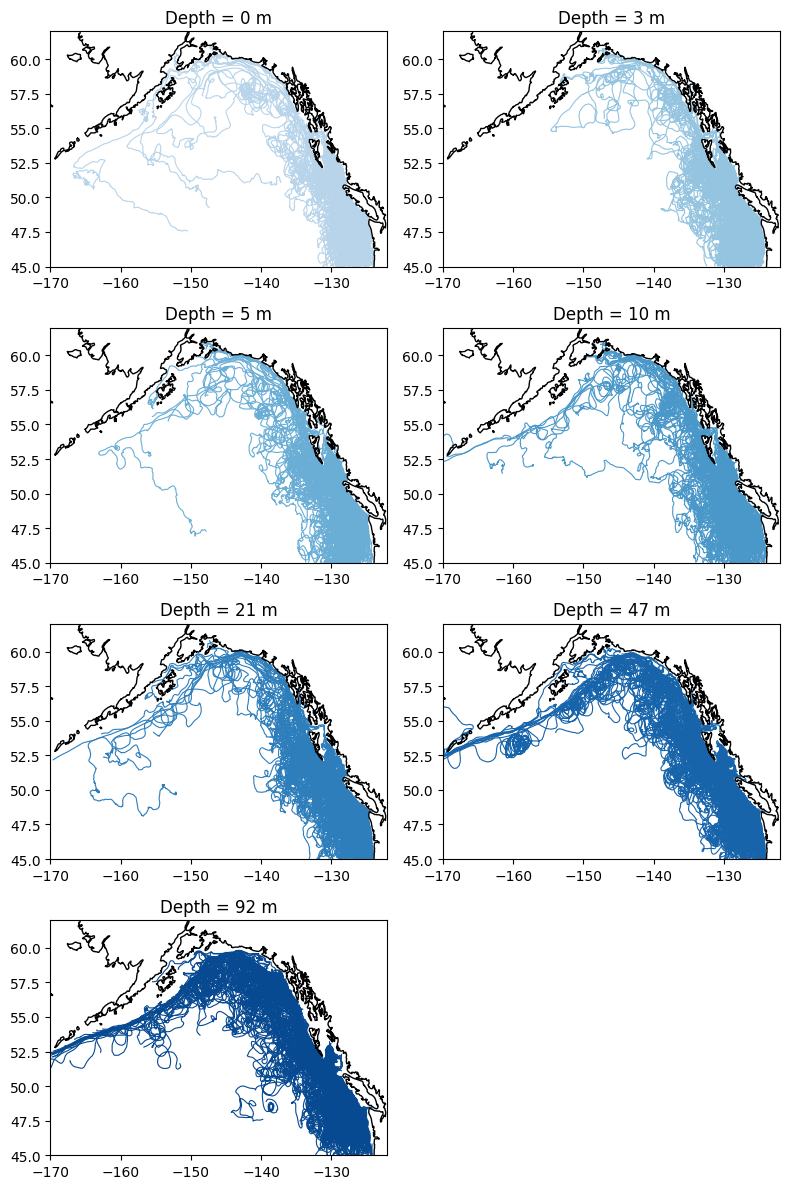

In [5]:
tracer='Haida'


depths =['0.5m','2.65m','5.08m','9.57m','21.6m','47.37m','92.33m']
#colors = ['b','r','g','orange','magenta','k','limegreen','purple','skyblue']

cmap = plt.colormaps['Blues']
norm = mcolors.Normalize(vmin=0, vmax=len(depths)+3)

fig, ax = plt.subplots(4,2,figsize=(8,12))

for i, depth in enumerate(depths):
    axis = ax.flatten()[i]
    file=f'/oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/{tracer}_{depth}/all_particles_combined.nc'
    trajectories = xr.open_dataset(file, engine="netcdf4")
    lats,lons = trajectories.lat[::1000,:], trajectories.lon[::1000,:]
    initial= xr.open_dataset(HOME+f'particle-tracking/{tracer}_0/{tracer}_initial.nc')

    color = cmap(norm(i+3))
    for n in range(len(lons)):
        istart = int(np.where(~np.isnan(lons[n,:]))[0][0])
        iend = istart + 365*2
        axis.plot(lons[n,istart:iend],lats[n,istart:iend],color=color,linewidth=0.8)
    coastline(axis)
    axis.set_title(f'Depth = {np.round(float(depth[0:3]),0):.2g} m')

fig.delaxes(ax.flatten()[-1])
plt.tight_layout()

#plt.savefig('figures/A01.png',dpi=400,bbox_inches='tight')
plt.show();



In [75]:
tracer='Haida'
depth='47.37m'
file=f'/oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/{tracer}_{depth}_1993-2025/all_particles_combined.nc'
trajectories = xr.open_dataset(file, engine="netcdf4")
initial= xr.open_dataset(HOME+f'particle-tracking/{tracer}_0/{tracer}_initial.nc')
trajectories

<xarray.Dataset>
Dimensions:       (particle: 566400, time: 11800)
Coordinates:
  * particle      (particle) int64 0 1 2 3 4 5 6 7 8 ... 40 41 42 43 44 45 46 47
    release_date  datetime64[ns] ...
  * time          (time) datetime64[ns] 1993-01-01 1993-01-02 ... 2025-04-22
Data variables:
    lat           (particle, time) float64 ...
    lon           (particle, time) float64 ...
Attributes:
    description:  Trajectories of 48 particles released on 1993-01-01
    method:       RungeKutta
    other:        buffered velocities around land
    depth:        47.37m
    history:      Thu Jun  5 21:25:37 2025: ncrcat /oscar/data/deeps/private/...
    NCO:          netCDF Operators version 5.1.5 (Homepage = http://nco.sf.ne...

In [77]:
0.1*86400/1e3

8.64